In [ ]:
from pathlib import Path
import jax.numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

from gwfast.gwfastGlobals import detectors as det_dict, detPath
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.signals import AGNLensedGWSignal
import gwfast.network as network
import gwfast.lensing_utils_alt as lutils

LSC Algorithm Library (LAL) is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH
TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


In [2]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1
Initializing jax...
Jax local device count: 1
Jax device count: 1


In [10]:
n = 30
shape = (n, n, n)
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24), 
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5), 
    'tcoal':np.full(shape, 0), 'phase':np.full(shape, 2), 
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.5),
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4), 
    'dL':np.full(shape, 0.8), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66), 
}
events = {key: val.astype(np.float64) for key, val in events.items()}

# Sample parameter space
R_orbit_array = np.geomspace(20, 5000, n)
src_pos_array = np.geomspace(0.02, 0.99, n)
dL_array = np.geomspace(0.1, 10, n)

# Make grid
R_orbit_mesh, src_pos_mesh, dL_mesh = np.meshgrid(R_orbit_array, src_pos_array, dL_array, indexing='xy')
events['R_orbit'] = R_orbit_mesh
events['src_pos'] = src_pos_mesh
events['dL'] = dL_mesh

Text(0.5, 1.0, 'SNR for HLV Network at $d_L$ = 0.10 Gpc')

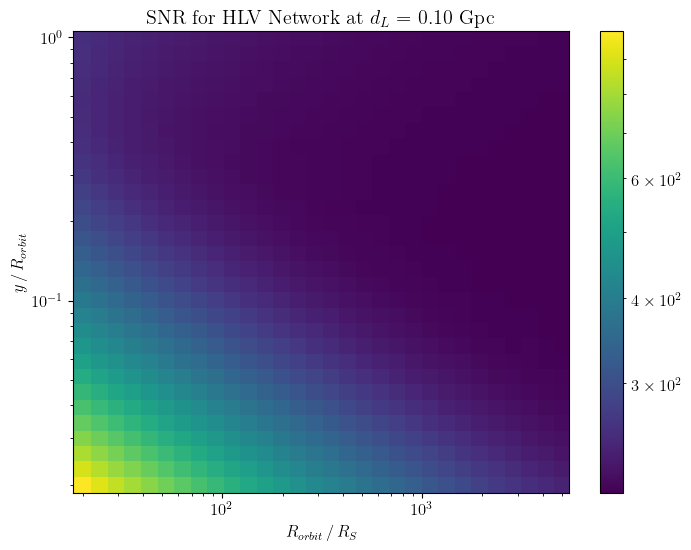

In [11]:
HLV_AGN_SNR_max = HLV_AGN.SNR({key: values[:, :, 0] for key, values in events.items()})
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
im = ax.pcolormesh(R_orbit_array, src_pos_array, HLV_AGN_SNR_max, 
                   norm=LogNorm()
                   )
fig.colorbar(im)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$R_{orbit}\,/\,R_S$')
ax.set_ylabel(r'$y\,/\,R_{orbit}$')
ax.set_title(r'SNR for HLV Network at $d_L$ = {:.2f} Gpc'.format(dL_array[0]))

In [28]:
import numpy as onp
from skimage.measure import marching_cubes
import pyvista as pv

def plot_isosurface(plotter, x_array, y_array, z_array, 
                    volume, level, label, color, opacity=0.7,
                    xscale=1, yscale=1, zscale=1):
    dx = x_array[1] - x_array[0]
    dy = y_array[1] - y_array[0]
    dz = z_array[1] - z_array[0]
    
    verts, faces, _, _ = marching_cubes(
        volume, level=level, spacing=(dx, dy, dz),
    )
    # Convert back to linear scale for plotting
    verts[:, 0] = onp.power(10, verts[:, 0] + x_array.min()) * xscale
    verts[:, 1] *= yscale
    verts[:, 2] = onp.power(10, verts[:, 2] + z_array.min()) * zscale

    # print(verts[:, 0], verts[:, 0].max())
    # print(verts[:, 1], verts[:, 1].max())
    # print(verts[:, 2], verts[:, 2].max())

    faces_pv = onp.hstack([[3, *face] for face in faces])
    mesh = pv.PolyData(verts, faces_pv)
    actor = plotter.add_mesh(mesh, color=color, opacity=opacity, show_edges=False, label=label)
    return mesh, actor

In [29]:
general_event_params = L1_AGN.convert_to_general_lensed_parameters(events)
delta_iota = onp.asarray(general_event_params['delta_iota'])
relative_mass = onp.asarray(general_event_params['relative_mass'])
print(delta_iota.max(), delta_iota.min(), delta_iota.mean())
print(relative_mass.max(), relative_mass.min(), relative_mass.mean())

0.4966709076873439 8.95379059748791e-05 0.04417779310571644
1.1076886202566973 1.0000569884127168 1.0175045788420827


In [35]:
n_point = 50
r_min, r_max = 20, 5000  # R_Sch
y_min, y_max = 0.02, 0.99  # R_orbit
d_min, d_max = 0.1, 10  # Gpc

log_r_min, log_r_max = onp.log10(r_min), onp.log10(r_max)
log_r_array = onp.linspace(log_r_min, log_r_max, n_point)
y_array = onp.linspace(y_min, y_max, n_point)
log_dL_min, log_dL_max = onp.log10(d_min), onp.log10(d_max)  # log(Gpc)
log_dL_array = onp.linspace(log_dL_min, log_dL_max, n_point)

delta_iota_levels = [1e-4, 1e-3, 1e-2, 1e-1]
labels = ['delta_iota = ' + str(i) + ' rad' for i in delta_iota_levels]
colors = ['midnightblue', 'teal', 'cadetblue', 'lightgreen']

xscale = 5000
zscale = 10

plotter = pv.Plotter()
for i in range(len(delta_iota_levels)):
    mesh, actor = plot_isosurface(
        plotter, log_r_array, y_array, log_dL_array,
        delta_iota, delta_iota_levels[i], labels[i], colors[i], 
        xscale=1/xscale, zscale=1/zscale
    )

plotter.show_bounds(
    xtitle=f'R_orbit / ({xscale:d} R_Sch)',
    ytitle='y / R_orbit',
    ztitle=f'dL / Gpc',
    grid='front',
    location='outer',
    all_edges=True
)

plotter.add_legend(
    size=(0.2, 0.1),
    loc='lower left'
)

plotter.show()

Widget(value='<iframe src="http://localhost:59538/index.html?ui=P_0x13d6b0940_11&reconnect=auto" class="pyvist…

In [36]:
relative_mass_levels = [1.02, 1.05, 1.08, 1.1]
labels = ['relative mass = ' + str(i) for i in relative_mass_levels]
colors = ['midnightblue', 'teal', 'cadetblue', 'lightgreen']

xscale = 5000
zscale = 10

plotter = pv.Plotter()
for i in range(len(relative_mass_levels)):
    mesh, actor = plot_isosurface(
        plotter, log_r_array, y_array, log_dL_array,
        relative_mass, relative_mass_levels[i], labels[i], colors[i], 
        xscale=1/xscale, zscale=1/zscale
    )

plotter.show_bounds(
    xtitle=f'R_orbit / ({xscale:d} R_Sch)',
    ytitle='y / R_orbit',
    ztitle=f'dL / Gpc',
    grid='front',
    location='outer',
    all_edges=True
)

plotter.add_legend(
    size=(0.2, 0.1),
    loc='lower left'
)

plotter.show()

Widget(value='<iframe src="http://localhost:59538/index.html?ui=P_0x13d6b0820_12&reconnect=auto" class="pyvist…